##  Importaciones

En este apartado importamos las librerias que vamos a necesitar

In [ ]:
!pip install livelossplot

In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt
import os
import seaborn as sns
import numpy as np
import tensorflow as tf
import random
from tensorflow.keras.utils import Sequence
from tensorflow.keras.preprocessing.image import load_img, img_to_array, random_rotation, random_zoom,random_shift
from livelossplot import PlotLossesKerasTF
import pandas as pd
import urllib
import zipfile
import shutil
from tensorflow.keras import regularizers
from collections import Counter
from PIL import Image
import random
import math
from tensorflow import keras
from tensorflow.keras import layers
from livelossplot import PlotLossesKeras
from tensorflow.keras.applications.vgg16 import preprocess_input

2026-04-09 15:00:29.170618: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775746829.561461      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775746829.684970      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775746830.673543      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775746830.673594      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775746830.673597      24 computation_placer.cc:177] computation placer alr

##  Descarga de los datos

A continuación descomprimimos los datos. Los he subido a Kaggle y los he usado desde ahí

In [ ]:
dataset_dir= '/kaggle/input/datasets/oscarniorobles/facialexpressionds/FacialExpressionDS'

In [ ]:
os.listdir(dataset_dir)

['data.yaml', 'valid', 'test', 'train']

Veamos a continuación cuántas imágenes hay en cada carpeta

In [ ]:
for folder in ['train','valid','test']:
  path = os.path.join(dataset_dir,folder,'images')
  if os.path.exists(path):
    num_items= len(os.listdir(path))
    print(f"La carpeta '{folder}' tiene '{num_items}' imágenes")

La carpeta 'train' tiene '17101' imágenes
La carpeta 'valid' tiene '5406' imágenes
La carpeta 'test' tiene '1760' imágenes


##  Análisis del conjunto de datos

Descarga el conjunto de datos (la URL está en la DATASET_URL) y analiza la estructura del conjunto de datos. Necesitará determinar el número de clases y como se dividen los datos.


Vemos el balanceo de clases a continuación

--- Conteo exacto por ID de clase ---
Clase '7': 2819 etiquetas
Clase '0': 2339 etiquetas
Clase '2': 2242 etiquetas
Clase '4': 2154 etiquetas
Clase '3': 2021 etiquetas
Clase '1': 1996 etiquetas
Clase '6': 1914 etiquetas
Clase '5': 1616 etiquetas


/tmp/ipykernel_24/2658180770.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=clases_ordenadas, y=cantidades_ordenadas, palette="magma")


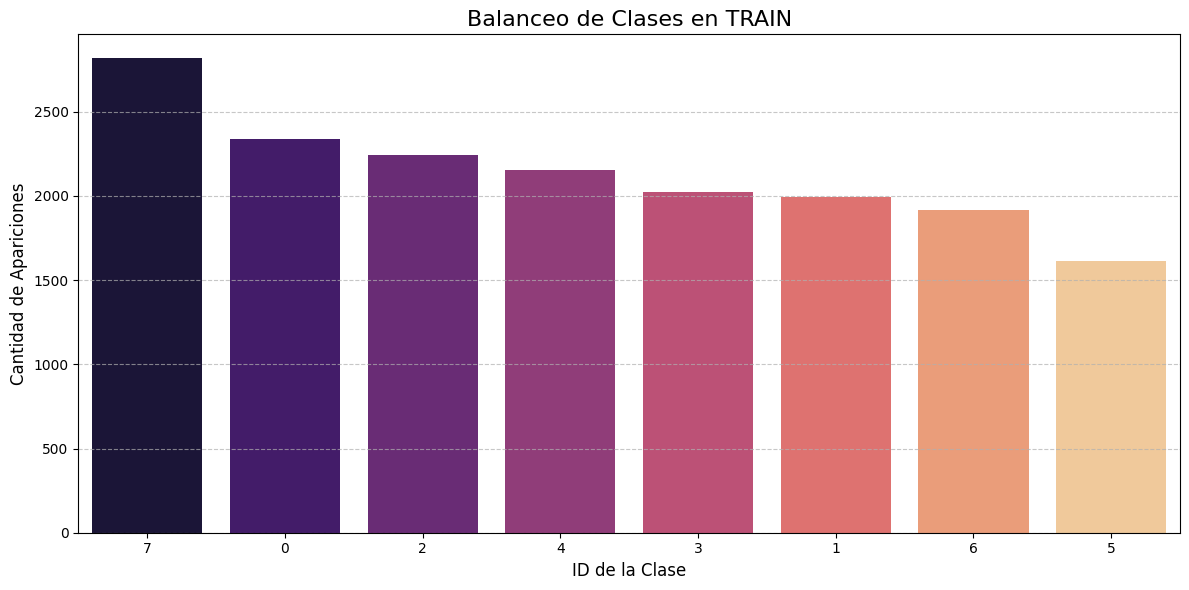

In [ ]:
# Rutas
dir_labels_train = '/kaggle/input/datasets/oscarniorobles/facialexpressionds/FacialExpressionDS/train/labels'

# Iniciamos un contador vacío
conteo_clases = Counter()

# Abrimos y leemos todos los .txt
archivos = os.listdir(dir_labels_train)
for archivo in archivos:
    if archivo.endswith('.txt'):
        ruta_archivo = os.path.join(dir_labels_train, archivo)
        with open(ruta_archivo, 'r') as f:
            lineas = f.readlines()
            for linea in lineas:
                partes = linea.strip().split()
                if partes: # Si la línea no está vacía
                    clase_id = partes[0]
                    conteo_clases[clase_id] += 1

# Preparamos los datos para la gráfica

clases_ordenadas = [item[0] for item in conteo_clases.most_common()]
cantidades_ordenadas = [item[1] for item in conteo_clases.most_common()]

print("--- Conteo exacto por ID de clase ---")
for c, cant in zip(clases_ordenadas, cantidades_ordenadas):
    print(f"Clase '{c}': {cant} etiquetas")

# Graficamos el balanceo
plt.figure(figsize=(12, 6))
sns.barplot(x=clases_ordenadas, y=cantidades_ordenadas, palette="magma")

plt.title('Balanceo de Clases en TRAIN', fontsize=16)
plt.xlabel('ID de la Clase', fontsize=12)
plt.ylabel('Cantidad de Apariciones', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

En train vemos que aunque las clases no están perfectamente balanceadas, sí que lo están relativamente

--- Conteo exacto por ID de clase ---
Clase '7': 874 etiquetas
Clase '4': 791 etiquetas
Clase '0': 712 etiquetas
Clase '2': 672 etiquetas
Clase '3': 622 etiquetas
Clase '1': 618 etiquetas
Clase '6': 603 etiquetas
Clase '5': 514 etiquetas


/tmp/ipykernel_24/3948441545.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=clases_ordenadas, y=cantidades_ordenadas, palette="magma")


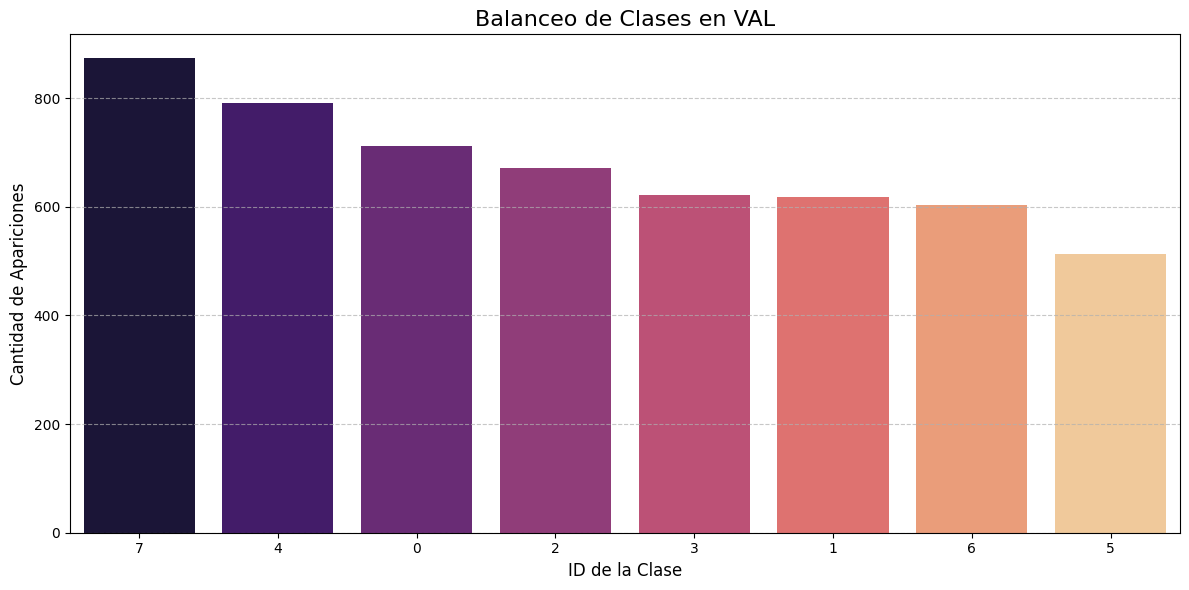

In [ ]:
dir_labels_val = '/kaggle/input/datasets/oscarniorobles/facialexpressionds/FacialExpressionDS/valid/labels'

conteo_clases = Counter()

archivos = os.listdir(dir_labels_val)
for archivo in archivos:
    if archivo.endswith('.txt'):
        ruta_archivo = os.path.join(dir_labels_val, archivo)
        with open(ruta_archivo, 'r') as f:
            lineas = f.readlines()
            for linea in lineas:
                partes = linea.strip().split()
                if partes:
                    clase_id = partes[0]
                    conteo_clases[clase_id] += 1


clases_ordenadas = [item[0] for item in conteo_clases.most_common()]
cantidades_ordenadas = [item[1] for item in conteo_clases.most_common()]

print("--- Conteo exacto por ID de clase ---")
for c, cant in zip(clases_ordenadas, cantidades_ordenadas):
    print(f"Clase '{c}': {cant} etiquetas")


plt.figure(figsize=(12, 6))
sns.barplot(x=clases_ordenadas, y=cantidades_ordenadas, palette="magma")

plt.title('Balanceo de Clases en VAL', fontsize=16)
plt.xlabel('ID de la Clase', fontsize=12)
plt.ylabel('Cantidad de Apariciones', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

Pasa igual que en train, las clases no están perfectamente balanceadas, pero tampoco lo suficientemente desbalanceadas para que sea alarmante.

Nos interesa también saber el tamaño de las imágenes por si hay que reescalarlas para introducirlas en la red convolucional.

Analizando 2000 imágenes...


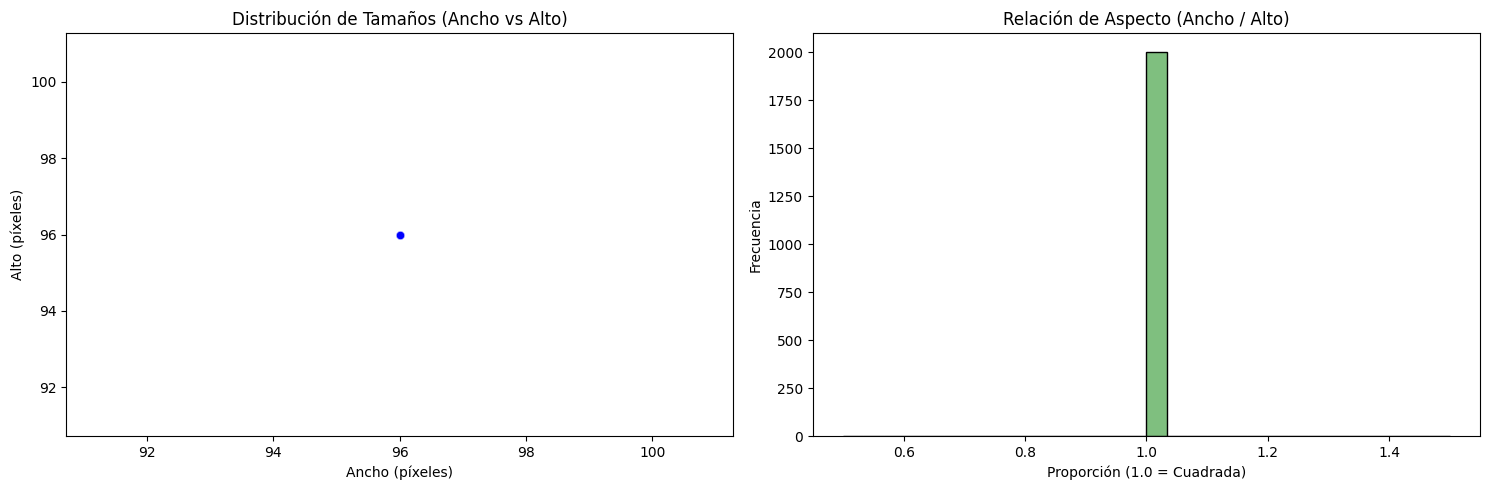

Ancho promedio: 96 px
Alto promedio: 96 px


In [ ]:
dir_images = '/kaggle/input/datasets/oscarniorobles/facialexpressionds/FacialExpressionDS/train/images'

anchos = []
altos = []
relaciones_aspecto = []

archivos_img = [f for f in os.listdir(dir_images) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

#Tomamos una muestra aleatoria (ej. 2000) para que sea instantáneo
muestra = random.sample(archivos_img, min(2000, len(archivos_img)))

print(f"Analizando {len(muestra)} imágenes...")

for archivo in muestra:
    ruta = os.path.join(dir_images, archivo)
    with Image.open(ruta) as img:
        ancho, alto = img.size
        anchos.append(ancho)
        altos.append(alto)
        relaciones_aspecto.append(ancho / alto)

# Gráficos
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Gráfico 1: Dispersión de Ancho vs Alto
sns.scatterplot(x=anchos, y=altos, alpha=0.5, ax=ax1, color='blue')
ax1.set_title('Distribución de Tamaños (Ancho vs Alto)')
ax1.set_xlabel('Ancho (píxeles)')
ax1.set_ylabel('Alto (píxeles)')

# Gráfico 2: Histograma de la Relación de Aspecto
sns.histplot(relaciones_aspecto, bins=30, kde=True, ax=ax2, color='green')
ax2.set_title('Relación de Aspecto (Ancho / Alto)')
ax2.set_xlabel('Proporción (1.0 = Cuadrada)')
ax2.set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

print(f"Ancho promedio: {int(sum(anchos)/len(anchos))} px")
print(f"Alto promedio: {int(sum(altos)/len(altos))} px")

Vemos que de la muestra aleatoria de 2000 imágenes que hemos tomado, todas tienen tamaño 96x96. Asumimos que ese es el tamaño de todas las imágenes

##  Generador de datos

Implementa un generador de datos de Keras para poder inyectar las entradas y las salidas a la red. Hacemos también data augmentation en los datos de train

In [ ]:
class CustomDataGenerator(tf.keras.utils.Sequence):

    def __init__(self, dir_images, dir_labels, batch_size=32, target_size=(96, 96), augment=False, **kwargs):
        super().__init__(**kwargs)
        self.dir_images = dir_images
        self.dir_labels = dir_labels
        self.batch_size = batch_size
        self.target_size = target_size
        self.augment = augment

        self.image_filenames = sorted([f for f in os.listdir(dir_images) if f.endswith('.png') or f.endswith('.jpg')])
        self.indices = np.arange(len(self.image_filenames))

    def __len__(self):
        return math.ceil(len(self.image_filenames) / self.batch_size)

    def _leer_etiqueta(self, nombre_imagen):
        nombre_base = os.path.splitext(nombre_imagen)[0]
        ruta_txt = os.path.join(self.dir_labels, f"{nombre_base}.txt")
        with open(ruta_txt, 'r') as f:
            linea = f.readline().strip().split()
            clase = int(linea[0])
        return clase


    def _augmentar(self, batch_x):
        for i in range(len(batch_x)):
            # 1. Flip y Brillo
            img_tensor = tf.convert_to_tensor(batch_x[i])
            if tf.random.uniform(()) > 0.5:
                img_tensor = tf.image.flip_left_right(img_tensor)
            img_tensor = tf.image.random_brightness(img_tensor, max_delta=0.15)
            batch_x[i] = img_tensor.numpy()
            # Rotación (solo de 5 a 8 grados máximo)
            batch_x[i] = random_rotation(batch_x[i], 7, row_axis=0, col_axis=1, channel_axis=2)

            # Zoom casi imperceptible (entre 0.95 y 1.05)
            batch_x[i] = random_zoom(batch_x[i], (0.95, 1.05), row_axis=0, col_axis=1, channel_axis=2)
            # Mueve la imagen un máximo del 5% (unos 4-5 píxeles) en cualquier dirección
            batch_x[i] = random_shift(batch_x[i], 0.05, 0.05, row_axis=0, col_axis=1, channel_axis=2)


        return batch_x

    def __getitem__(self, idx):
        batch_indices = self.indices[idx * self.batch_size : (idx + 1) * self.batch_size]
        batch_filenames = [self.image_filenames[i] for i in batch_indices]

        X = np.empty((len(batch_filenames), *self.target_size, 3), dtype=np.float32)
        y = np.empty((len(batch_filenames)), dtype=np.int32)

        for i, filename in enumerate(batch_filenames):
            ruta_img = os.path.join(self.dir_images, filename)
            img = load_img(ruta_img, target_size=self.target_size)
            X[i] = img_to_array(img) / 255.0
            y[i] = self._leer_etiqueta(filename)

        y_one_hot = tf.keras.utils.to_categorical(y, num_classes=8)

        if self.augment:
            X = self._augmentar(X)

            # --- NUEVO: CUTMIX AL 55% ---
            if np.random.rand() > 0.45:
                indices_shuffled = np.arange(len(X))
                np.random.shuffle(indices_shuffled)
                X_shuffled = X[indices_shuffled]
                y_shuffled = y_one_hot[indices_shuffled]

                lam = np.random.beta(1.0, 1.0)
                cut_ratio = np.sqrt(1. - lam)
                cut_w = int(96 * cut_ratio)
                cut_h = int(96 * cut_ratio)
                cx = np.random.randint(96)
                cy = np.random.randint(96)

                bbx1 = np.clip(cx - cut_w // 2, 0, 96)
                bby1 = np.clip(cy - cut_h // 2, 0, 96)
                bbx2 = np.clip(cx + cut_w // 2, 0, 96)
                bby2 = np.clip(cy + cut_h // 2, 0, 96)

                X[:, bbx1:bbx2, bby1:bby2, :] = X_shuffled[:, bbx1:bbx2, bby1:bby2, :]

                area_real = (bbx2 - bbx1) * (bby2 - bby1)
                lam_real = 1. - (area_real / (96.0 * 96.0))
                y_one_hot = lam_real * y_one_hot + (1. - lam_real) * y_shuffled

        return X, y_one_hot
    def on_epoch_end(self):
        np.random.shuffle(self.indices)

Usamos **CUTMIX** y también hacer *data augmentation* mediante **zoooms, rotaciones y movimiento de la imágen**

In [ ]:
# Rutas
dir_train_img = '/kaggle/input/datasets/oscarniorobles/facialexpressionds/FacialExpressionDS/train/images'
dir_train_lbl = '/kaggle/input/datasets/oscarniorobles/facialexpressionds/FacialExpressionDS/train/labels'
dir_val_img = '/kaggle/input/datasets/oscarniorobles/facialexpressionds/FacialExpressionDS/valid/images'
dir_val_lbl = '/kaggle/input/datasets/oscarniorobles/facialexpressionds/FacialExpressionDS/valid/labels'

# Crear los generadores
# Augment=True solo para entrenamiento
train_generator = CustomDataGenerator(dir_train_img, dir_train_lbl, batch_size=128, target_size=(96, 96), augment=True)


val_generator = CustomDataGenerator(dir_val_img, dir_val_lbl, batch_size=128, target_size=(96, 96), augment=False)

# Comprobación rápida para ver si funciona bien
X_batch_prueba, y_batch_prueba = train_generator[0]
print("Forma del lote de imágenes:", X_batch_prueba.shape) # Debería ser (64, 96, 96, 3)
print("Forma del lote de etiquetas:", y_batch_prueba.shape) # Debería ser (64,)
print("Ejemplo de etiquetas del primer lote:", y_batch_prueba[:10])

I0000 00:00:1775747107.674277      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1775747107.680290      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Forma del lote de imágenes: (128, 96, 96, 3)
Forma del lote de etiquetas: (128, 8)
Ejemplo de etiquetas del primer lote: [[0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 1. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0.]]


## Clasificador de expresiones faciales



La arquitectura tiene las siguientes características



*   **BLOQUE SE** (Squeeze-Excitation): Aprende a prestar atención a los canales importantes, para ello recalibra los mapas de características, multiplicando y dándole más peso a los canales de información más relevantes.
*   **USO DE *SWISH* COMO FUNCIÓN DE ACTIVACIÓN**: Es menos agresiva que ReLU (que hay veces que literalmente mata neuronas), siwsh en cambio es más suave.

*   **ELIMINACIÓN DE MAX POOLING**: Usamos `strides=2` para reducir la imágen en lugar de *max pooling* por la misma razón que antes, tiene un tratamiento más suave.
*   **SPATIAL DROPOUT**: En lugar de dropout que desactiva neuronas individuales, hemos usado spatial droput que desactiva mapas de características completos.

*   **USO DE L2** (muy ligero): En los modelos que probaba L2 acaban ahogandose, por eso en este lo he puesto de manera muy ligera en la capa densa, sustituyendo al método de regularización `label smooting` ya que ambos actúan de forma similar en este caso (evitar que el modelo sea arrogante y se confíe mucho en sus predicciones).
*   **USO DE GAP, BLOQUES RESIDUALES Y BATCH NORMALIZATION**.







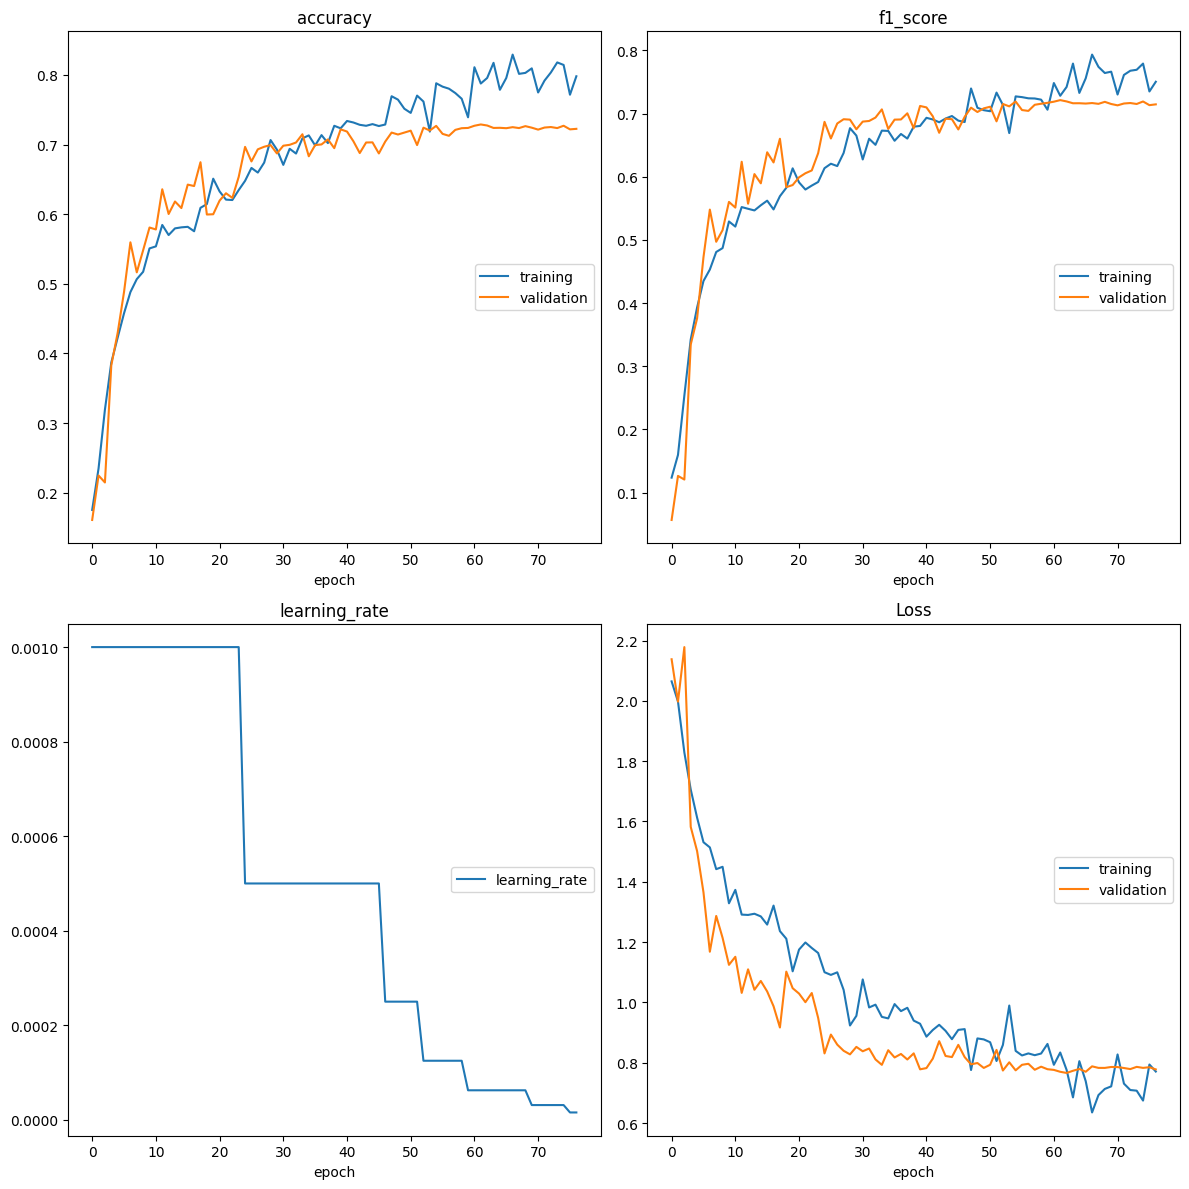

accuracy
	training         	 (min:    0.175, max:    0.829, cur:    0.798)
	validation       	 (min:    0.161, max:    0.729, cur:    0.723)
f1_score
	training         	 (min:    0.124, max:    0.793, cur:    0.750)
	validation       	 (min:    0.057, max:    0.721, cur:    0.715)
learning_rate
	learning_rate    	 (min:    0.000, max:    0.001, cur:    0.000)
Loss
	training         	 (min:    0.635, max:    2.065, cur:    0.771)
	validation       	 (min:    0.766, max:    2.178, cur:    0.778)
134/134 ━━━━━━━━━━━━━━━━━━━━ 172s 1s/step - accuracy: 0.7873 - f1_score: 0.7465 - loss: 0.7724 - val_accuracy: 0.7225 - val_f1_score: 0.7146 - val_loss: 0.7781 - learning_rate: 1.5625e-05


In [ ]:
NUM_CLASES = 8

def se_block(tensor, ratio=16):
    """Bloque Squeeze-and-Excitation: Aprende a prestar atención a los canales importantes."""
    filtros = tensor.shape[-1]

    # Squeeze: Aplasta la imagen para sacar un resumen global
    se = layers.GlobalAveragePooling2D()(tensor)

    # Excitation: Red neuronal en miniatura que decide qué canales importan
    se = layers.Dense(filtros // ratio, activation='swish')(se)
    se = layers.Dense(filtros, activation='sigmoid')(se)

    # Multiplica la imagen original por los "pesos de atención"
    # Aseguramos que las dimensiones encajen para multiplicar
    se = layers.Reshape((1, 1, filtros))(se)
    return layers.multiply([tensor, se])

def bloque_residual_avanzado(x, filtros, stride=1):
    # Guardamos la entrada para la conexión residual (el atajo)
    shortcut = x

    # Primera convolución (stride=2, reducimos imagen aquí, sin MaxPooling)
    x = layers.Conv2D(filtros, (3, 3), strides=stride, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('swish')(x)

    # Segunda convolución
    x = layers.Conv2D(filtros, (3, 3), strides=1, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)

    # Le aplicamos la atención
    x = se_block(x)

    # Ajustamos el atajo si hemos reducido la imagen (stride=2) o aumentado los filtros
    if stride != 1 or shortcut.shape[-1] != filtros:
        shortcut = layers.Conv2D(filtros, (1, 1), strides=stride, padding='same', use_bias=False)(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)

    # Suma residual y activación final
    x = layers.Add()([shortcut, x])
    x = layers.Activation('swish')(x)
    return x


strategy = tf.distribute.MirroredStrategy()

with strategy.scope():
    inputs = keras.Input(shape=(96, 96, 3))

    # --- FASE 1: Inicial y reducción a 48x48 ---
    # En lugar de VGG, usamos convoluciones directas con Swish
    x = layers.Conv2D(32, (3, 3), padding='same', activation='swish')(inputs)
    x = layers.BatchNormalization()(x)
    # Reducción inteligente a 48x48 (sustituye al primer MaxPooling)
    x = bloque_residual_avanzado(x, 32, stride=2)

    # --- FASE 2: Profundidad Residual (64 filtros) y reducción a 24x24 ---
    x = bloque_residual_avanzado(x, 64)
    # Reducción inteligente a 24x24 (sustituye al segundo MaxPooling)
    x = bloque_residual_avanzado(x, 64, stride=2)

    # --- FASE 3: Más profundidad (128 filtros) y reducción a 12x12 ---
    x = bloque_residual_avanzado(x, 128)
    # Reducción inteligente a 12x12 (sustituye al tercer MaxPooling)
    x = bloque_residual_avanzado(x, 128, stride=2)

    # --- FASE 4: Especialización final (256 filtros) ---
    x = bloque_residual_avanzado(x, 256)
    x = bloque_residual_avanzado(x, 256) # Añadimos uno extra para potencia final

    # --- CLASIFICACIÓN FINAL ---
    x = layers.SpatialDropout2D(0.2)(x)
    x = layers.GlobalAveragePooling2D()(x)
   # Micro-L2 en la capa Densa para evitar confianza extrema
    x = layers.Dense(128, activation='swish', kernel_regularizer=tf.keras.regularizers.l2(1e-5))(x)
    outputs = layers.Dense(8, activation='softmax')(x)

    model = keras.Model(inputs=inputs, outputs=outputs)

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy', tf.keras.metrics.F1Score(average='macro', name='f1_score')]
    )


#Creamos callbacks que son obligatorios
callbacks_resnet_final = [
    # Le damos 15 épocas enteras de margen para superar un estancamiento
    keras.callbacks.EarlyStopping(
        monitor='val_f1_score',
        mode='max',
        patience=15,
        restore_best_weights=True
    ),
    # Guardamos el mejor modelo
    keras.callbacks.ModelCheckpoint(
        filepath='/kaggle/working/modelo_kaggle.keras',
        monitor='val_f1_score',
        mode='max',
        save_best_only=True
    ),
    # Si se atasca 6 épocas, dividimos la tasa de aprendizaje a la mitad para afinar
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=6,
        min_lr=1e-6
    ), PlotLossesKeras()
]

historia_final = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=100,
    callbacks=callbacks_resnet_final
)

**COMENTARIOS**
El modelo está bien regularizado, ni está muy sobreajustado ni está ahogado (como me ha pasado con otras pruebas), parece que ya empezaba una poco a ajustar después de casi 80 epochs, pero hemos obtenido un valor de val_f1_score de 0.7146 que está bastante bien.


Se han usado los comandos `strategy = tf.distribute.MirroredStrategy()` y`with strategy.scope():` porque Kaggle tiene como GPU gratis T4x2 es decir, dos gráficas en paralelo y hay que llamar a los comandos para que se usen las dos

En la siguiente celda tengo un entrenamiento que hice con transfer learning pero lo tuve que comentar y no ejecutar porque Kaggle ejecuta el cuaderno entero y ya había probado que ese modelo no mejoraba respecto a los que ya tenía así que era una tontería ejecutarlo de nuevo.

In [ ]:
# import tensorflow as tf
# from tensorflow import keras
# from tensorflow.keras import layers

# NUM_CLASES = 8

# # 1. Importamos un modelo pre-entrenado
# # include_top=False significa que le quitamos su clasificador de 1000 clases para poner el nuestro de 8
# base_model = tf.keras.applications.VGG16(
#     include_top=False,
#     weights="imagenet",
#     input_shape=(96, 96, 3)
# )

# # 2. CONGELAMOS la red base para no destruir lo que ya sabe
# for layer in base_model.layers:
#     layer.trainable = False

# # 3. Construimos nuestra red acoplando la base
# inputs = keras.Input(shape=(96, 96, 3))

# # Conectamos la entrada a la VGG16
# x = base_model(inputs, training=False)

# # 4. Agregamos nuestras capas de clasificación
# x = layers.GlobalAveragePooling2D()(x)
# x = layers.Dense(256, activation='relu')(x)
# x = layers.Dropout(0.5)(x)
# outputs = layers.Dense(NUM_CLASES, activation='softmax')(x)

# # 5. Empaquetamos todo
# modelo = keras.Model(inputs=inputs, outputs=outputs)

# # COMPILAMOS (Mantenemos tu Label Smoothing y el F1-Score)
# modelo.compile(
#     optimizer=keras.optimizers.Adam(learning_rate=0.001),
#     loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
#     metrics=['accuracy', tf.keras.metrics.F1Score(average='macro', name='f1_score')]
# )

# # --- 1. CONFIGURAMOS LOS CALLBACKS ---
# mis_callbacks_vgg = [
#     # Freno de emergencia: si en 8 épocas no mejora, paramos y rescatamos los mejores pesos
#     keras.callbacks.EarlyStopping(
#         monitor='val_f1_score', # Vigilamos nuestra métrica estrella
#         mode='max',
#         patience=8,
#         restore_best_weights=True
#     ),
#     # Guardado automático
#     keras.callbacks.ModelCheckpoint(
#         filepath='/content/campeon_vgg16.keras',
#         monitor='val_f1_score',
#         mode='max',
#         save_best_only=True
#     ),
#     # Reducimos el learning rate si se atasca para que afine la puntería
#     keras.callbacks.ReduceLROnPlateau(
#         monitor='val_loss',
#         factor=0.5,
#         patience=3,
#         min_lr=1e-6
#     )
# ]

# # --- 2. ¡ARRANCAMOS EL ENTRENAMIENTO! ---
# print("Iniciando entrenamiento con Transfer Learning (VGG16)...")

# historia_vgg = model.fit(
#     train_generator,
#     validation_data=val_generator,
#     epochs=40, # Le damos margen, el EarlyStopping cortará cuando sea necesario
#     callbacks=mis_callbacks_vgg
# )


Hacemos un summary del modelo

In [ ]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 96, 96, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 96, 96,    │        896 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 96, 96,    │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 48, 48,    │      9,216 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 48, 48,    │        128 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 48, 48,    │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 48, 48,    │      9,216 │ activation[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 48, 48,    │        128 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 32)        │          0 │ batch_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 2)         │         66 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 32)        │         96 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 48, 48,    │      1,024 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 1, 1, 32)  │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 48, 48,    │        128 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 48, 48,    │          0 │ batch_normalizat… │
│                     │ 32)               │            │ reshape[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 48, 48,    │          0 │ batch_normalizat… │
│                     │ 32)               │            │ multiply[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 48, 48,    │          0 │ add[0][0]         │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 48, 48,    │     18,432 │ activation_1[0][

 Total params: 8,570,152 (32.69 MB)

 Trainable params: 2,855,010 (10.89 MB)

 Non-trainable params: 5,120 (20.00 KB)

 Optimizer params: 5,710,022 (21.78 MB)

Ahora vamos a guardar el modelo

In [ ]:
model.save('modelo_earlystopping.h5')

También tenemos guardado el modelo que se nos guardó automáticamente con el mayor val_f1_score.

## Conclusiones e investigación

Tras haber cargado muchos muchos pero que muchos modelos puedo afirmar con prácticamente toda mi confianza que los datos simplemente no dejan que el modelo aprenda más. Ya no es tema de arquitectura ni de regularización. Cuanto aquí como ha sido mi desasarrollo investigador estas dos semanas y a qué conclusiones he llegado.

**Semana pasada**: Aquí fue una búsqueda ciega y desesperada tanto de arquitectura como de algunos métodos de regularización  para conseguir el mejor modelo posible. En esta semana afiancé la arquitectura (también probé usando Inception por ejemplo pero esta fue la que mejor me resuletado me dió).

**Esta semana**: La idea ha sido continuar con la misma arquitectura que fue la que mejor resultado me dió la semana pasada y a partir de esa meterle más regularización a ver que se alcanzaba. Al insertar muchas cosas de golpe el modelo se ahogaba y teníamos *underfitting*, pero si no ponía las suficientes regularizaciones el modelo sobreajustaba. En ningún caso conseguía romper esa marca de un 70% aprox de fscore. La investigación semanal ha sido más bien buscar el punto óptimo entre muy poca y mucha regularización para ver si así consguía romper ese techo (probar distintos métodos de regularización o incluso con los mismos métodos de regularización probar los umbrales de cada uno). Ha sido todo ensayo y error hasta que he llegado a este modelo que parece que está equilibrado y aun así no he consigo alcanzar mejores resultados.

A la conclusión que llego entonces es que simplemente con esos datos no se puede aprender más. El límite de aprendizaje es ese, da un poco igual cuánto afinemos el modelo y la regularización en este caso que no se va a poder aprender mucho más. Se me ocurren dos formas de combatir contra esto:



*   Más volumen de datos. Cuántos más datos, más información tenemos. Quizás así se podría afinar más el modelo.
*   Otros métodos independientes del modelo. Por ejemplo, se podrián tomar tres o más modelos distintos y hacer **ensamblado**, es decir cada modelo actúa de juez y tiene un voto. Cada imagen la predicción con más votos será la predicción final. Esto podría mejorar el rendimiento de las predicciones aunque no mejore el modelo en sí. Otra técnica simple que la he realizado con las predicciones simplemente por ilustrar, es simplemente tomar batches con la misma imagen modificada de distintas maneras y hacer la predicción sobre todas las imágenes y hacer las medias de las probabilidades. Esto fuerza al modelo a que tenga que estar más seguro. Se podrían estudiar las probabilidades para ver entre qué clasificaciones duda el modelo.

